# Train Forecast Models (optimized)

This notebook trains separate models for **temperature**, **humidity**, **wind_mph**, and **uv_index**.
It includes careful preprocessing to avoid data leakage, per-location training, model saving, evaluation, and a sample crop recommendation step.

**Paths used:** `climatescope/data/processed/normalized_weather_data.csv` -> data
`climatescope/models/` -> saved models

Run cells sequentially.

In [12]:
# Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [56]:
# Paths configuration
BASE_DIR = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "processed" / "normalized_weather_data.csv"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("MODEL_DIR:", MODEL_DIR)

DATA_PATH: c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\data\processed\normalized_weather_data.csv
MODEL_DIR: c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models


In [ ]:
#MODEL_DIR = BASE_DIR / "models"
# Remove all existing .pkl files in MODEL_DIR
#for f in MODEL_DIR.glob("*.pkl"):
#    print(f"Deleting {f}")
#    f.unlink()

Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\'S_Gravenjansdijk__humidity_rf.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\'S_Gravenjansdijk__scaler.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\'S_Gravenjansdijk__temperature_celsius_rf.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\'S_Gravenjansdijk__uv_index_rf.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\'S_Gravenjansdijk__wind_mph_rf.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\Abuja__humidity_rf.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\Abuja__scaler.pkl
Deleting c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosy

In [58]:
# Load data
assert DATA_PATH.exists(), f"Data file not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df.columns

Raw shape: (97240, 34)


Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius', 'wind_mph',
       'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud',
       'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_mph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination', 'condition_text',
       'wind_direction', 'moon_phase', 'sunrise', 'sunset', 'moonrise',
       'moonset'],
      dtype='object')

In [59]:
# Basic preview and cleaning
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
print("Last updated - min/max:", df['last_updated'].min(), df['last_updated'].max())

# Drop rows missing the primary timestamp
df = df.dropna(subset=['last_updated'])
# Optional: drop exact duplicate rows
df = df.drop_duplicates()
print("After dropna/dups:", df.shape)

# Show sample
df.head()


Last updated - min/max: 2024-05-16 01:45:00 2025-09-28 21:15:00
After dropna/dups: (97240, 34)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_degree,...,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,condition_text,wind_direction,moon_phase,sunrise,sunset,moonrise,moonset
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,0.424360,0.021732,1.627115,...,-0.805520,-0.686071,0.150335,partly cloudy,nnw,waxing gibbous,4:50 AM,6:50 PM,12:12 PM,1:11 AM
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,-0.463700,-0.252721,1.451870,...,-0.805520,-0.686071,0.150335,partly cloudy,nw,waxing gibbous,5:21 AM,7:54 PM,12:58 PM,2:14 AM
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,0.003700,0.237373,1.062437,...,-0.805520,-0.686071,0.150335,sunny,w,waxing gibbous,5:40 AM,7:50 PM,1:15 PM,2:14 AM
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,-1.947695,-0.154702,0.429607,...,-0.805520,-0.686071,0.150335,light drizzle,sw,waxing gibbous,6:31 AM,9:11 PM,2:12 PM,3:31 AM
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,0.354250,-0.017476,-0.203222,...,0.059176,2.818386,0.150335,partly cloudy,sse,waxing gibbous,6:12 AM,5:55 PM,1:17 PM,12:38 AM


## Feature selection & strategy

"
"We train **separate** models per location for each target. This notebook uses the following features (can be extended):

"
"- `temperature_celsius` (target 1)
- `humidity` (target 2)
- `wind_mph` (target 3)
- `uv_index` (target 4)

"
"Predictors used (examples): `pressure_mb`, `precip_mm`, `feels_like_celsius`, `air_quality_PM2.5`, plus lagged versions of the same metrics.

"
"Important: scalers are fit ONLY on training data to avoid leakage.


In [60]:
# Create features: choose predictors and add month/lag features

# Sort data by timestamp
df = df.sort_values('last_updated')

# Select numeric columns that may be useful
candidate_features = [
    'pressure_mb', 'precip_mm', 'feels_like_celsius', 'air_quality_PM2.5',
    'temperature_celsius', 'humidity', 'wind_mph', 'uv_index'
]

# Keep only columns that exist
candidate_features = [c for c in candidate_features if c in df.columns]

# --- Clean numeric columns to handle invalid entries like '#NAME?' ---
for col in candidate_features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')  # convert invalid strings to NaN

# Optional: fill missing numeric values with column mean
df[candidate_features] = df[candidate_features].fillna(df[candidate_features].mean())

# Add month and year as features
df['month'] = df['last_updated'].dt.month
df['year'] = df['last_updated'].dt.year

# --- Compute monthly mean aggregates per location ---
df_monthly = (
    df.set_index('last_updated')
      .groupby('location_name')[candidate_features]
      .resample('M')
      .mean()
      .reset_index()
)

# Rename date column for consistency
df_monthly = df_monthly.rename(columns={'last_updated': 'ds'})

print("Monthly shape:", df_monthly.shape)
df_monthly.head()


Monthly shape: (3459, 10)


,location_name,ds,pressure_mb,precip_mm,feels_like_celsius,air_quality_PM2.5,temperature_celsius,humidity,wind_mph,uv_index
0,#NAME?,2024-07-31,-1.583809,-0.358374,0.376627,-0.833427,0.786595,-1.659619,0.629447,0.879122
1,'S Gravenjansdijk,2024-05-31,0.009772,0.736476,-0.793682,-0.867105,-0.814250,0.738076,1.805672,0.039328
2,'S Gravenjansdijk,2024-06-30,-0.169186,0.201266,-0.360384,-0.747004,-0.342038,0.006123,0.440329,0.203993
3,'S Gravenjansdijk,2024-07-31,0.061512,0.199838,-0.219767,-0.766673,-0.200787,-0.044423,0.351494,0.329257
4,'S Gravenjansdijk,2024-08-31,0.051832,-0.069743,0.035274,-0.705234,0.070041,-0.320750,0.446058,0.545010


In [61]:
# --- Create lag features (lag 1 and lag 2 months) per location ---

# Add month and year again (since after resampling they got dropped)
df_monthly['month'] = df_monthly['ds'].dt.month
df_monthly['year'] = df_monthly['ds'].dt.year

# Create lag features
lags = [1, 2]
for lag in lags:
    lagged = df_monthly.groupby('location_name')[candidate_features].shift(lag)
    lagged.columns = [f"{col}_lag{lag}" for col in lagged.columns]
    df_monthly = pd.concat([df_monthly, lagged], axis=1)

# Define prediction targets
targets = ['temperature_celsius', 'humidity', 'wind_mph', 'uv_index']
available_targets = [t for t in targets if t in df_monthly.columns]
print("Targets used:", available_targets)

# Keep only relevant columns
use_cols = (
    ['ds', 'location_name', 'month', 'year']
    + available_targets
    + [c for c in df_monthly.columns if 'lag' in c or c in candidate_features]
)

# Filter columns safely (only existing ones)
use_cols = [c for c in use_cols if c in df_monthly.columns]
df_monthly = df_monthly[use_cols]

# Drop rows with any NaNs (caused by lagging or missing data)
df_monthly = df_monthly.dropna().reset_index(drop=True)

print("After dropping NA rows:", df_monthly.shape)
df_monthly.head()


Targets used: ['temperature_celsius', 'humidity', 'wind_mph', 'uv_index']
After dropping NA rows: (2907, 32)


,ds,location_name,month,year,temperature_celsius,humidity,wind_mph,uv_index,pressure_mb,precip_mm,...,wind_mph_lag1,uv_index_lag1,pressure_mb_lag2,precip_mm_lag2,feels_like_celsius_lag2,air_quality_PM2.5_lag2,temperature_celsius_lag2,humidity_lag2,wind_mph_lag2,uv_index_lag2
0,2024-07-31,'S Gravenjansdijk,7,2024,-0.200787,-0.044423,0.351494,0.329257,0.061512,0.199838,...,0.440329,0.203993,0.009772,0.736476,-0.793682,-0.867105,-0.814250,0.738076,1.805672,0.039328
1,2024-08-31,'S Gravenjansdijk,8,2024,0.070041,-0.320750,0.446058,0.545010,0.051832,-0.069743,...,0.351494,0.329257,-0.169186,0.201266,-0.360384,-0.747004,-0.342038,0.006123,0.440329,0.203993
2,2024-09-30,'S Gravenjansdijk,9,2024,-0.494470,0.264049,0.869266,0.225948,-0.014373,0.163979,...,0.446058,0.545010,0.061512,0.199838,-0.219767,-0.766673,-0.200787,-0.044423,0.351494,0.329257
3,2024-10-31,'S Gravenjansdijk,10,2024,-1.105998,0.836758,0.459338,-0.683076,0.229416,-0.165953,...,0.869266,0.225948,0.051832,-0.069743,0.035274,-0.705234,0.070041,-0.320750,0.446058,0.545010
4,2024-11-30,'S Gravenjansdijk,11,2024,-1.717890,0.972334,0.471964,-0.989887,0.859682,0.012869,...,0.459338,-0.683076,-0.014373,0.163979,-0.537984,-0.383995,-0.494470,0.264049,0.869266,0.225948


In [62]:
# Check how many rows each location has
location_counts = df_monthly['location_name'].value_counts().sort_values(ascending=False)
display(location_counts.head(20))

# Minimum, maximum, and average records per location
print("Min rows per location:", location_counts.min())
print("Max rows per location:", location_counts.max())
print("Avg rows per location:", location_counts.mean())

location_name
Lusaka                 15
Baku                   15
Bern                   15
Amman                  15
Andorra La Vella       15
Ashgabat               15
Asmara                 15
Astana                 15
Athens                 15
Ankara                 15
Baghdad                15
Bamako                 15
Stockholm              15
Bandar Seri Begawan    15
Berlin                 15
Bangkok                15
Bangui                 15
Banjul                 15
Basseterre             15
Beijing                15
Name: count, dtype: int64

Min rows per location: 1
Max rows per location: 15
Avg rows per location: 14.756345177664974


In [64]:
# --- GLOBAL MODEL (all locations combined) ---
df_monthly = df_monthly.sort_values('ds')

# Split last 12 months as test
train_df = df_monthly.iloc[:-12]
test_df = df_monthly.iloc[-12:]

X_train, X_test = train_df[feature_cols].values, test_df[feature_cols].values

# Scale features (one scaler for all targets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save global scaler
scaler_path = MODEL_DIR / "global_scaler.pkl"
joblib.dump(scaler, scaler_path)

train_report = []

# Train one model per target
for target in available_targets:
    y_train, y_test = train_df[target].values, test_df[target].values

    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save global model per target
    model_path = MODEL_DIR / f"{target}_rf.pkl"
    joblib.dump(model, model_path)

    train_report.append({
        "target": target,
        "mae": mae,
        "r2": r2,
        "rows_train": len(train_df),
        "rows_test": len(test_df),
        "model_path": str(model_path),
        "scaler_path": str(scaler_path)
    })

report_df = pd.DataFrame(train_report)
display(report_df)
print("✅ Global models trained per target.")



,target,mae,r2,rows_train,rows_test,model_path,scaler_path
0,temperature_celsius,0.047945,0.993305,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
1,humidity,0.227463,0.936483,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
2,wind_mph,0.279949,0.400054,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
3,uv_index,0.177181,0.886953,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...


✅ Global models trained per target.


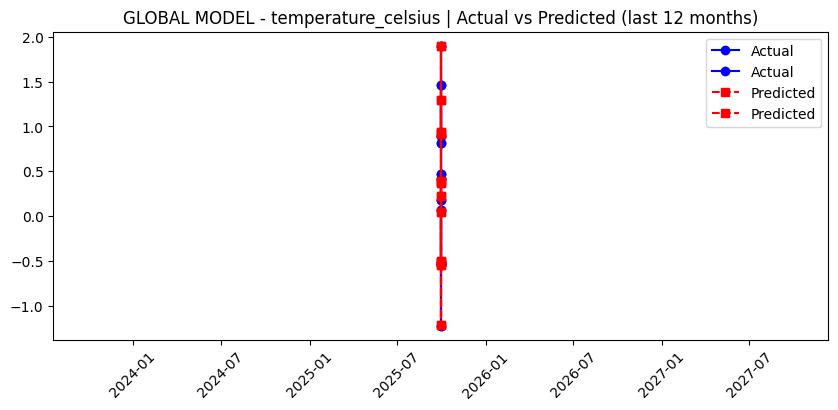

In [66]:
# --- Quick diagnostic plots for GLOBAL models ---
if not report_df.empty:
    # Pick first target for plotting
    sample_row = report_df.iloc[0]
    target = sample_row['target']
    model_path = sample_row['model_path']
    scaler_path = sample_row['scaler_path']

    # Load global model and scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    # Prepare test data
    X_test = test_df[feature_cols].values
    X_test_scaled = scaler.transform(X_test)
    y_test = test_df[target].values
    y_pred = model.predict(X_test_scaled)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(test_df['ds'], y_test, marker='o', markersize=6, color='blue', linestyle='-', label='Actual')
    plt.plot(test_df['ds'], y_pred, marker='s', markersize=6, color='red', linestyle='--', label='Predicted')
    plt.xticks(rotation=45)
    plt.legend()
    plt.title(f"GLOBAL MODEL - {target} | Actual vs Predicted (last 12 months)")
    plt.show()
else:
    print("No global models trained; check earlier cells.")


In [67]:
# --- Save global training report ---
out_report = MODEL_DIR / "training_report.csv"
report_df.to_csv(out_report, index=False)
print('✅ Saved global training report to', out_report)
report_df.head()

✅ Saved global training report to c:\Users\devar\OneDrive\Documents\Projects\climatescope-infosys-project\climatescope\models\training_report.csv


,target,mae,r2,rows_train,rows_test,model_path,scaler_path
0,temperature_celsius,0.047945,0.993305,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
1,humidity,0.227463,0.936483,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
2,wind_mph,0.279949,0.400054,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...
3,uv_index,0.177181,0.886953,2895,12,c:\Users\devar\OneDrive\Documents\Projects\cli...,c:\Users\devar\OneDrive\Documents\Projects\cli...


## Crop recommendation example

"
"The notebook includes a simple scoring function. To keep reproducible, add an example usage below.


In [73]:
# Simple crop profiles (example) - refine with agronomy data
CROP_PROFILES = {
  "Wheat": {
      "temp": (10, 25),
      "humidity": (50, 85),
      "uv_index": (1, 8),
      "precip_mm": (20, 120),
      "wind_mph": (0, 12),
      "best_months": [10, 11, 12, 1, 2, 3],

      # 🌍 Extended agro-climatic fields:
      "soil_type": ["Loam", "Clay Loam"],
      "soil_ph": (6.0, 7.5),
      "elevation_m": (0, 2500),
      "sunshine_hours": (6, 9),
      "rainy_days": (40, 120),
      "frost_tolerance": True,
      "heat_tolerance": False,
      "drought_tolerance": "Medium",
      "water_requirement_mm": (400, 800),
      "gdd_range": (1800, 2500),  # Growing Degree Days
      "sowing_depth_cm": (3, 5),
      "harvest_time_days": (120, 150),
      "fertilizer_npk_kg_per_ha": {"N": 120, "P": 60, "K": 40},
      "irrigation_frequency_days": (7, 15),
      "light_intensity_lux": (20000, 60000),
      "seed_rate_kg_per_ha": (100, 125),
      "yield_t_per_ha": (2.5, 5.0),
      "pests": ["Aphids", "Armyworm", "Rust"],
      "diseases": ["Leaf Rust", "Powdery Mildew", "Smuts"],
      "common_varieties": ["HD2967", "PBW343", "Lok1"],
      "major_regions": {
            "India": ["Punjab", "Haryana", "Uttar Pradesh"],
            "USA": ["Iowa", "Kansas", "Nebraska"],
            "China": ["Henan", "Shandong", "Hebei"]
        }
  },
  "Maize": {
    "temp": (18, 30),
    "humidity": (50, 85),
    "uv_index": (3, 9),
    "precip_mm": (400, 1200),
    "wind_mph": (0, 15),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam"],
    "soil_ph": (5.5, 7.0),
    "elevation_m": (0, 2500),
    "sunshine_hours": (6, 10),
    "rainy_days": (60, 140),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (500, 800),
    "gdd_range": (1500, 2800),
    "sowing_depth_cm": (3, 6),
    "harvest_time_days": (90, 130),
    "fertilizer_npk_kg_per_ha": {"N": 150, "P": 75, "K": 60},
    "irrigation_frequency_days": (7, 12),
    "light_intensity_lux": (25000, 60000),
    "seed_rate_kg_per_ha": (20, 25),
    "yield_t_per_ha": (4.0, 10.0),
    "pests": ["Fall Armyworm", "Corn Borer", "Aphids"],
    "diseases": ["Downy Mildew", "Leaf Blight", "Rust"],
    "common_varieties": ["Ganga-5", "Vivek Hybrid-9", "HQPM-1"],
    "major_regions": {
        "India": ["Karnataka", "Andhra Pradesh", "Madhya Pradesh"],
        "USA": ["Iowa", "Illinois", "Nebraska"],
        "Brazil": ["Paraná", "Mato Grosso", "Goias"]
    }
},
"Rice": {
    "temp": (20, 35),
    "humidity": (70, 95),
    "uv_index": (3, 8),
    "precip_mm": (1000, 2500),
    "wind_mph": (0, 10),
    "best_months": [6, 7, 8, 9, 10],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Clay", "Clay Loam", "Silty Loam"],
    "soil_ph": (5.5, 7.0),
    "elevation_m": (0, 1500),
    "sunshine_hours": (5, 8),
    "rainy_days": (80, 200),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Low",
    "water_requirement_mm": (900, 2500),
    "gdd_range": (2000, 3000),
    "sowing_depth_cm": (2, 4),
    "harvest_time_days": (120, 150),
    "fertilizer_npk_kg_per_ha": {"N": 100, "P": 50, "K": 50},
    "irrigation_frequency_days": (5, 10),
    "light_intensity_lux": (20000, 50000),
    "seed_rate_kg_per_ha": (30, 40),
    "yield_t_per_ha": (3.0, 7.0),
    "pests": ["Brown Planthopper", "Stem Borer", "Leaf Folder"],
    "diseases": ["Blast", "Bacterial Leaf Blight", "Sheath Blight"],
    "common_varieties": ["IR64", "Swarna", "MTU-1010"],
    "major_regions": {
        "India": ["West Bengal", "Odisha", "Tamil Nadu"],
        "China": ["Guangdong", "Hunan", "Jiangsu"],
        "Vietnam": ["Mekong Delta", "Red River Delta"]
    }
},
"Barley": {
    "temp": (8, 25),
    "humidity": (40, 70),
    "uv_index": (2, 7),
    "precip_mm": (250, 750),
    "wind_mph": (0, 15),
    "best_months": [11, 12, 1, 2, 3, 4],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Clay Loam"],
    "soil_ph": (6.0, 7.5),
    "elevation_m": (0, 2000),
    "sunshine_hours": (5, 9),
    "rainy_days": (30, 90),
    "frost_tolerance": True,
    "heat_tolerance": False,
    "drought_tolerance": "High",
    "water_requirement_mm": (300, 500),
    "gdd_range": (1200, 1800),
    "sowing_depth_cm": (3, 6),
    "harvest_time_days": (90, 120),
    "fertilizer_npk_kg_per_ha": {"N": 80, "P": 40, "K": 40},
    "irrigation_frequency_days": (10, 20),
    "light_intensity_lux": (15000, 45000),
    "seed_rate_kg_per_ha": (80, 100),
    "yield_t_per_ha": (2.0, 4.5),
    "pests": ["Aphids", "Armyworms", "Thrips"],
    "diseases": ["Leaf Rust", "Powdery Mildew", "Smuts"],
    "common_varieties": ["RD-2035", "PL-172", "BH-393"],
    "major_regions": {
        "India": ["Rajasthan", "Uttar Pradesh", "Haryana"],
        "Germany": ["Bavaria", "Lower Saxony", "Saxony-Anhalt"],
        "Australia": ["Western Australia", "Victoria", "New South Wales"]
    }
},"Sorghum": {
    "temp": (25, 35),
    "humidity": (40, 70),
    "uv_index": (5, 10),
    "precip_mm": (400, 1000),
    "wind_mph": (0, 15),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Red Soil"],
    "soil_ph": (5.5, 7.5),
    "elevation_m": (0, 1800),
    "sunshine_hours": (7, 10),
    "rainy_days": (40, 100),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "High",
    "water_requirement_mm": (400, 600),
    "gdd_range": (1500, 2500),
    "sowing_depth_cm": (2, 5),
    "harvest_time_days": (100, 120),
    "fertilizer_npk_kg_per_ha": {"N": 100, "P": 50, "K": 40},
    "irrigation_frequency_days": (10, 15),
    "light_intensity_lux": (30000, 60000),
    "seed_rate_kg_per_ha": (8, 12),
    "yield_t_per_ha": (2.0, 4.0),
    "pests": ["Shoot Fly", "Stem Borer", "Armyworm"],
    "diseases": ["Anthracnose", "Smut", "Downy Mildew"],
    "common_varieties": ["CSH-16", "CSV-15", "SPV-462"],
    "major_regions": {
        "India": ["Maharashtra", "Karnataka", "Telangana"],
        "Nigeria": ["Kano", "Kaduna", "Bauchi"],
        "USA": ["Texas", "Kansas", "Oklahoma"]
    }
},
"Soybean": {
    "temp": (20, 30),
    "humidity": (60, 85),
    "uv_index": (4, 9),
    "precip_mm": (500, 900),
    "wind_mph": (0, 12),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Clay Loam", "Silty Loam"],
    "soil_ph": (6.0, 7.5),
    "elevation_m": (0, 1800),
    "sunshine_hours": (6, 9),
    "rainy_days": (50, 120),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (450, 700),
    "gdd_range": (1200, 2000),
    "sowing_depth_cm": (3, 5),
    "harvest_time_days": (100, 130),
    "fertilizer_npk_kg_per_ha": {"N": 20, "P": 60, "K": 40},
    "irrigation_frequency_days": (7, 12),
    "light_intensity_lux": (25000, 55000),
    "seed_rate_kg_per_ha": (50, 75),
    "yield_t_per_ha": (2.0, 4.0),
    "pests": ["Stem Fly", "Leaf Miner", "Pod Borer"],
    "diseases": ["Rust", "Bacterial Blight", "Yellow Mosaic Virus"],
    "common_varieties": ["JS-335", "Pusa-9712", "MAUS-71"],
    "major_regions": {
        "India": ["Madhya Pradesh", "Maharashtra", "Rajasthan"],
        "USA": ["Illinois", "Iowa", "Minnesota"],
        "Brazil": ["Paraná", "Mato Grosso", "Rio Grande do Sul"]
    }
},
"Groundnut": {
    "temp": (20, 35),
    "humidity": (50, 80),
    "uv_index": (5, 10),
    "precip_mm": (500, 1000),
    "wind_mph": (0, 10),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Sandy Loam", "Loamy Sand", "Red Soil"],
    "soil_ph": (5.8, 7.2),
    "elevation_m": (0, 1000),
    "sunshine_hours": (6, 9),
    "rainy_days": (40, 100),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "High",
    "water_requirement_mm": (500, 700),
    "gdd_range": (1500, 2000),
    "sowing_depth_cm": (4, 6),
    "harvest_time_days": (100, 140),
    "fertilizer_npk_kg_per_ha": {"N": 25, "P": 50, "K": 50},
    "irrigation_frequency_days": (10, 15),
    "light_intensity_lux": (25000, 60000),
    "seed_rate_kg_per_ha": (80, 100),
    "yield_t_per_ha": (1.5, 3.0),
    "pests": ["Aphids", "Leaf Miner", "Pod Borer"],
    "diseases": ["Tikka Disease", "Rust", "Bud Necrosis"],
    "common_varieties": ["JL-24", "TAG-24", "ICGV-91114"],
    "major_regions": {
        "India": ["Gujarat", "Andhra Pradesh", "Tamil Nadu"],
        "Nigeria": ["Kaduna", "Kano", "Sokoto"],
        "China": ["Shandong", "Henan", "Hebei"]
    }
},
"Cotton": {
    "temp": (21, 35),
    "humidity": (50, 70),
    "uv_index": (6, 10),
    "precip_mm": (600, 1200),
    "wind_mph": (0, 15),
    "best_months": [6, 7, 8, 9, 10],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Black Soil", "Loam", "Alluvial Soil"],
    "soil_ph": (6.0, 8.0),
    "elevation_m": (0, 1200),
    "sunshine_hours": (7, 10),
    "rainy_days": (50, 100),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (700, 1200),
    "gdd_range": (1800, 3000),
    "sowing_depth_cm": (2, 5),
    "harvest_time_days": (160, 200),
    "fertilizer_npk_kg_per_ha": {"N": 100, "P": 60, "K": 60},
    "irrigation_frequency_days": (10, 15),
    "light_intensity_lux": (30000, 70000),
    "seed_rate_kg_per_ha": (15, 25),
    "yield_t_per_ha": (1.0, 2.5),
    "pests": ["Bollworm", "Aphids", "Whitefly"],
    "diseases": ["Wilt", "Leaf Curl Virus", "Anthracnose"],
    "common_varieties": ["BT Cotton", "LRA-5166", "Bunny BT"],
    "major_regions": {
        "India": ["Maharashtra", "Gujarat", "Punjab"],
        "USA": ["Texas", "Mississippi", "Georgia"],
        "China": ["Xinjiang", "Hebei", "Hubei"]
    }
},
"Sugarcane": {
    "temp": (20, 35),
    "humidity": (65, 90),
    "uv_index": (4, 9),
    "precip_mm": (1000, 2000),
    "wind_mph": (0, 12),
    "best_months": [10, 11, 12, 1, 2, 3],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Clay Loam", "Alluvial Soil"],
    "soil_ph": (6.0, 7.5),
    "elevation_m": (0, 1200),
    "sunshine_hours": (6, 9),
    "rainy_days": (100, 180),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (1500, 2500),
    "gdd_range": (3000, 4500),
    "sowing_depth_cm": (10, 15),
    "harvest_time_days": (300, 450),
    "fertilizer_npk_kg_per_ha": {"N": 200, "P": 100, "K": 100},
    "irrigation_frequency_days": (7, 15),
    "light_intensity_lux": (30000, 65000),
    "seed_rate_kg_per_ha": (2500, 3000),  # cane setts per ha
    "yield_t_per_ha": (60, 120),
    "pests": ["Early Shoot Borer", "Root Borer", "White Grub"],
    "diseases": ["Red Rot", "Smut", "Ratoon Stunting"],
    "common_varieties": ["Co-86032", "Co-0238", "CoC-671"],
    "major_regions": {
        "India": ["Uttar Pradesh", "Maharashtra", "Tamil Nadu"],
        "Brazil": ["São Paulo", "Pernambuco", "Paraná"],
        "Thailand": ["Khon Kaen", "Nakhon Sawan", "Kanchanaburi"]
    }
},
"Millet": {
    "temp": (20, 32),
    "humidity": (35, 70),
    "uv_index": (4, 9),
    "precip_mm": (300, 900),
    "wind_mph": (0, 15),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Red Soil"],
    "soil_ph": (5.0, 7.5),
    "elevation_m": (0, 2000),
    "sunshine_hours": (6, 10),
    "rainy_days": (45, 120),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "High",
    "water_requirement_mm": (350, 600),
    "gdd_range": (1400, 2200),
    "sowing_depth_cm": (2, 4),
    "harvest_time_days": (90, 120),
    "fertilizer_npk_kg_per_ha": {"N": 40, "P": 20, "K": 20},
    "irrigation_frequency_days": (10, 18),
    "light_intensity_lux": (20000, 60000),
    "seed_rate_kg_per_ha": (4, 8),
    "yield_t_per_ha": (1.0, 3.0),
    "pests": ["Shoot Fly", "Stem Borer", "Aphids"],
    "diseases": ["Blast", "Smuts", "Downy Mildew"],
    "common_varieties": ["VL Mandua 101", "VL Mandua 149", "KM-65"],
    "major_regions": {
        "India": ["Rajasthan", "Karnataka", "Maharashtra"],
        "Nigeria": ["Kano", "Kaduna", "Bauchi"],
        "Ethiopia": ["Oromia", "Amhara", "Tigray"]
    }
},
"Finger Millet": {
    "temp": (20, 30),
    "humidity": (30, 65),
    "uv_index": (4, 8),
    "precip_mm": (400, 1000),
    "wind_mph": (0, 15),
    "best_months": [6, 7, 8, 9],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Light Red Soil"],
    "soil_ph": (4.5, 8.0),    # as reported. :contentReference[oaicite:7]{index=7}
    "elevation_m": (0, 2000),
    "sunshine_hours": (6, 10),
    "rainy_days": (50, 120),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "High",    # noted as resilient to stress. :contentReference[oaicite:8]{index=8}
    "water_requirement_mm": (450, 800),
    "gdd_range": (1600, 2400),
    "sowing_depth_cm": (2, 4),
    "harvest_time_days": (90, 115),
    "fertilizer_npk_kg_per_ha": {"N": 40, "P": 20, "K": 20},    # typical broad recommendation. :contentReference[oaicite:9]{index=9}
    "irrigation_frequency_days": (12, 20),
    "light_intensity_lux": (20000, 55000),
    "seed_rate_kg_per_ha": (5, 10),
    "yield_t_per_ha": (1.0, 2.5),
    "pests": ["Shoot Fly", "Leaf Miner", "Armyworm"],
    "diseases": ["Blast", "Neck Blast", "Smuts"],
    "common_varieties": ["VL Mandua 101", "VL Mandua 204", "KM-65"],
    "major_regions": {
        "India": ["Karnataka", "Telangana", "Maharashtra"],
        "Uganda": ["Eastern Region", "Western Region", "Central"],
        "Kenya": ["Rift Valley", "Western", "Central"]
    }
},
"Rapeseed/Mustard": {
    "temp": (10, 30),
    "humidity": (45, 75),
    "uv_index": (3, 8),
    "precip_mm": (300, 650),
    "wind_mph": (0, 12),
    "best_months": [10, 11, 12, 1, 2, 3],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Alluvial", "Black Soil"],
    "soil_ph": (6.0, 8.5),
    "elevation_m": (0, 1500),
    "sunshine_hours": (5, 8),
    "rainy_days": (40, 90),
    "frost_tolerance": False,
    "heat_tolerance":  True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (200, 400),    # low water requirement: 80-240 mm noted for rainfed. :contentReference[oaicite:10]{index=10}
    "gdd_range": (1300, 2000),
    "sowing_depth_cm": (1, 3),
    "harvest_time_days": (130, 160),
    "fertilizer_npk_kg_per_ha": {"N": 50, "P": 40, "K": 40},
    "irrigation_frequency_days": (15, 20),
    "light_intensity_lux": (18000, 50000),
    "seed_rate_kg_per_ha": (5, 8),
    "yield_t_per_ha": (1.5, 3.0),
    "pests": ["Aphids", "Cabbage Caterpillar", "Mustard Sawfly"],
    "diseases": ["Sclerotinia Stem Rot", "Alternaria Leaf Spot", "White Rust"],
    "common_varieties": ["Varuna", "Pusa Bold", "RH 749"],
    "major_regions": {
        "India": ["Rajasthan", "Uttar Pradesh", "Haryana"],
        "Canada": ["Saskatchewan", "Alberta", "Manitoba"],
        "China": ["Hubei", "Shandong", "Henan"]
    }
},
"Sunflower": {
    "temp": (18, 30),
    "humidity": (40, 70),
    "uv_index": (5, 10),
    "precip_mm": (400, 900),
    "wind_mph": (0, 15),
    "best_months": [3, 4, 5, 6],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Black Soil"],
    "soil_ph": (6.0, 7.5),
    "elevation_m": (0, 1200),
    "sunshine_hours": (6, 9),
    "rainy_days": (45, 110),
    "frost_tolerance": False,
    "heat_tolerance": True,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (450, 700),
    "gdd_range": (1200, 2000),
    "sowing_depth_cm": (2, 4),
    "harvest_time_days": (90, 120),
    "fertilizer_npk_kg_per_ha": {"N": 70, "P": 40, "K": 40},
    "irrigation_frequency_days": (12, 20),
    "light_intensity_lux": (25000, 60000),
    "seed_rate_kg_per_ha": (4, 6),
    "yield_t_per_ha": (1.0, 2.5),
    "pests": ["Sunflower Moth", "Aphids", "Stem Weevil"],
    "diseases": ["Downy Mildew", "Rust", "Phoma Black Stem"],
    "common_varieties": ["KBSH-44", "PAC-36", "SF-187"],
    "major_regions": {
        "India": ["Karnataka", "Maharashtra", "Andhra Pradesh"],
        "Ukraine": ["Kherson", "Dnipropetrovsk", "Mykolaiv"],
        "Argentina": ["Buenos Aires", "La Pampa", "Santa Fe"]
    }
},
"Tomato": {
    "temp": (18, 25),
    "humidity": (60, 90),
    "uv_index": (4, 8),
    "precip_mm": (500, 1200),
    "wind_mph": (0, 12),
    "best_months": [10, 11, 12, 1, 2, 3],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Light Loam", "Sandy Loam", "Alluvial"],
    "soil_ph": (5.0, 7.0),    # Prefers 5-7. :contentReference[oaicite:11]{index=11}
    "elevation_m": (0, 1500),
    "sunshine_hours": (5, 8),
    "rainy_days": (60, 140),
    "frost_tolerance": False,
    "heat_tolerance": False,    # sensitive to >25 °C + high humidity causing yield drop. :contentReference[oaicite:12]{index=12}
    "drought_tolerance": "Low",
    "water_requirement_mm": (600, 1000),
    "gdd_range": (1100, 1700),
    "sowing_depth_cm": (1, 2),
    "harvest_time_days": (90, 150),
    "fertilizer_npk_kg_per_ha": {"N": 100, "P": 65, "K": 160},    # high‐producing varieties. :contentReference[oaicite:13]{index=13}
    "irrigation_frequency_days": (5, 10),
    "light_intensity_lux": (20000, 45000),
    "seed_rate_kg_per_ha": (20, 30),
    "yield_t_per_ha": (30, 60),    # note this is fruit yield, so scale is different
    "pests": ["Tomato Fruit Borer", "Whitefly", "Aphids"],
    "diseases": ["Bacterial Wilt", "Late Blight", "Tomato Mosaic Virus"],
    "common_varieties": ["Pusa Ruby", "Arka Vijaya", "Hybrid Punjab Chandni"],
    "major_regions": {
        "India": ["Haryana", "Andhra Pradesh", "Karnataka"],
        "USA": ["California", "Florida", "Ohio"],
        "China": ["Shandong", "Guangdong", "Hebei"]
    }
},
"Potato": {
    "temp": (10, 25),
    "humidity": (60, 90),
    "uv_index": (3, 7),
    "precip_mm": (500, 1200),
    "wind_mph": (0, 10),
    "best_months": [9, 10, 11, 12, 1, 2],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Sandy Loam", "Loam", "Clay Loam"],
    "soil_ph": (5.5, 7.0),    # Ideal pH 5.5-7.0. :contentReference[oaicite:14]{index=14}
    "elevation_m": (0, 2000),
    "sunshine_hours": (5, 8),
    "rainy_days": (50, 120),
    "frost_tolerance": True,    # grows in subtropical with care. :contentReference[oaicite:15]{index=15}
    "heat_tolerance": True,
    "drought_tolerance": "Low",
    "water_requirement_mm": (700, 1200),
    "gdd_range": (900, 1500),
    "sowing_depth_cm": (8, 12),
    "harvest_time_days": (90, 120),
    "fertilizer_npk_kg_per_ha": {"N": 150, "P": 60, "K": 100},
    "irrigation_frequency_days": (7, 12),
    "light_intensity_lux": (15000, 40000),
    "seed_rate_kg_per_ha": (2000, 3000),    # seed tubers
    "yield_t_per_ha": (20, 40),
    "pests": ["Potato Tuber Moth", "Aphids", "Wireworm"],
    "diseases": ["Late Blight", "Early Blight", "Black Scurf"],
    "common_varieties": ["Kufri Jyoti", "Kufri Chamatkar", "Atlantic"],
    "major_regions": {
        "India": ["Uttar Pradesh", "West Bengal", "Bihar"],
        "USA": ["Idaho", "Washington", "Colorado"],
        "China": ["Hebei", "Sichuan", "Yunnan"]
    }
},
"Chickpea": {
    "temp": (18, 30),
    "humidity": (30, 65),
    "uv_index": (3, 8),
    "precip_mm": (300, 650),
    "wind_mph": (0, 12),
    "best_months": [10, 11, 12, 1, 2, 3],

    # 🌍 Extended agro-climatic fields:
    "soil_type": ["Loam", "Sandy Loam", "Red Soil"],
    "soil_ph": (6.0, 8.0),
    "elevation_m": (0, 1500),
    "sunshine_hours": (6, 9),
    "rainy_days": (30, 70),
    "frost_tolerance": False,
    "heat_tolerance": False,
    "drought_tolerance": "Medium",
    "water_requirement_mm": (350, 600),
    "gdd_range": (1200, 1900),
    "sowing_depth_cm": (2, 4),
    "harvest_time_days": (100, 130),
    "fertilizer_npk_kg_per_ha": {"N": 20, "P": 40, "K": 30},
    "irrigation_frequency_days": (12, 20),
    "light_intensity_lux": (20000, 50000),
    "seed_rate_kg_per_ha": (60, 80),
    "yield_t_per_ha": (1.0, 2.5),
    "pests": ["Pod Borer", "Aphids", "Thrips"],
    "diseases": ["Ascochyta Blight", "Fusarium Wilt", "Root Rot"],
    "common_varieties": ["JG 11", "Pb 99-12", "AKT-8812"],
    "major_regions": {
        "India": ["Madhya Pradesh", "Maharashtra", "Rajasthan"],
        "Australia": ["Victoria", "South Australia", "New South Wales"],
        "Turkey": ["Konya", "Ankara", "Eskişehir"]
    }
}
}


def score_crop(pred_row, profile):
    score = 0
    reasons = []
    # temp
    t = pred_row.get('temperature_celsius', np.nan)
    if pd.notna(t):
        if profile['temp'][0] <= t <= profile['temp'][1]:
            score += 2
            reasons.append('temp ideal')
        elif min(abs(t-profile['temp'][0]), abs(t-profile['temp'][1])) <= 2:
            score += 1
            reasons.append('temp close')
    # humidity
    h = pred_row.get('humidity', np.nan)
    if pd.notna(h):
        if profile['humidity'][0] <= h <= profile['humidity'][1]:
            score += 1
            reasons.append('humidity ok')
    # precip
    p = pred_row.get('precip_mm', np.nan)
    if pd.notna(p):
        if profile['precip_mm'][0] <= p <= profile['precip_mm'][1]:
            score += 1
            reasons.append('precip ok')
    # uv index
    u = pred_row.get('uv_index', np.nan)
    if pd.notna(u) and 'uv_index' in profile:
        if profile['uv_index'][0] <= u <= profile['uv_index'][1]:
            score += 0.5
            reasons.append('uv ok')

    # wind speed
    w = pred_row.get('wind_mph', np.nan)
    if pd.notna(w) and 'wind_mph' in profile:
        if profile['wind_mph'][0] <= w <= profile['wind_mph'][1]:
            score += 0.5
            reasons.append('wind ok')
        elif min(abs(w - profile['wind_mph'][0]), abs(w - profile['wind_mph'][1])) <= 2:
            score += 0.25
            reasons.append('wind close')
    
    # 🌱 Boolean & categorical checks
    # frost tolerance
    frost = pred_row.get('frost', False)
    if 'frost_tolerance' in profile:
        if profile['frost_tolerance'] == frost:
            score += 0.5
            reasons.append('frost tolerance ok')

    # heat tolerance
    heat = pred_row.get('heat', False)
    if 'heat_tolerance' in profile:
        if profile['heat_tolerance'] == heat:
            score += 0.5
            reasons.append('heat tolerance ok')

    # drought tolerance
    drought = pred_row.get('drought', 'Medium')  # assume default Medium
    if 'drought_tolerance' in profile:
        if profile['drought_tolerance'].lower() == drought.lower():
            score += 0.5
            reasons.append('drought tolerance match')

    return score, reasons
